In [239]:
from astropy.time import Time
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.dates import date2num
import numpy as np
import matplotlib.patches as patches


In [240]:
# Julian dates stored in text files must have this bias added to them when they
# are converted to conventional julian dates (eg, with AstroPy).
JULDATE_BIAS = 2440000.0

def read_obs_pred_file(pred_file, no_date_parse=False, no_juldate_bias=False):
    """Return parsed obs or pred file.

    Args
       pred_file: Path to pred file
       no_date_parse: (optional) set to true to disable parsing dates,
         which is much faster.
    Returns
       Pandas data frame with the juldate column replaced with datetime
       instances.
    """
    if no_juldate_bias:
        juldate_offset = 0
    else:
        juldate_offset = JULDATE_BIAS

    df = pd.read_csv(pred_file, sep='\\s+', comment='#')

    if not no_date_parse:
        df['juldate'] = [
            Time(float(s) + juldate_offset, format='jd').to_datetime()
            for s in df['juldate']
        ]
    
    return df

In [241]:
def read_locs_file(locs_file):
    locs_df = pd.read_csv(
          locs_file, delim_whitespace=True,
          names=['sat_time_jd', 'sat_lon', 'carrot_num', 'sat_lat', 'radii']
    )
 
    locs_df['juldate'] = Time(locs_df.sat_time_jd, format='jd').to_datetime()

    return locs_df

# Load Data

In [242]:
df_pred_stereo = read_obs_pred_file('wsa-v7/wsa/WSA_WORKING/DefaultGroup/Mars_L1_Stereo_Analysis/PREDSOLARWIND/field_line_03_R000_gongz_stereoa.dat')
df_pred_earth = read_obs_pred_file('wsa-v7/wsa/WSA_WORKING/DefaultGroup/Mars_L1_Stereo_Analysis/PREDSOLARWIND/field_line_03_R000_gongz_earth.dat')

In [243]:
df_pred_stereo.juldate.min()

Timestamp('2007-01-03 16:40:22.079989')

In [244]:
df_pred_stereo.juldate.max()

Timestamp('2026-01-03 11:16:56.640003')

In [245]:
df_obs_stereo = read_obs_pred_file('wsa-v7/WSA_DATA/DATA/SATELLITES/STEREOA/stereoA_L2_hr.dat')
df_obs_earth = read_obs_pred_file('wsa-v7/WSA_DATA/DATA/SATELLITES/ACEL2/acel2_hr.dat')

In [246]:
df_locs_stereo = read_locs_file('wsa-v7/WSA_DATA/DATA/SATELLITES/STEREOA/stereoA_locs.dat')
df_locs_earth = read_locs_file('wsa-v7/WSA_DATA/DATA/SATELLITES/ACE/Ace_locs.dat')

/home/dedasilv/.micromamba/envs/WSA-v7/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 4019 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/dedasilv/.micromamba/envs/WSA-v7/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 7670 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [247]:
df_locs_stereo

,sat_time_jd,sat_lon,carrot_num,sat_lat,radii,juldate
0,2454035.5,248.559466,2049.309557,4.870339,0.992692,2006-10-27
1,2454036.5,235.374313,2049.346182,4.778076,0.991757,2006-10-28
2,2454037.5,222.188236,2049.382810,4.685918,0.991063,2006-10-29
3,2454038.5,209.001832,2049.419439,4.592887,0.990528,2006-10-30
4,2454039.5,195.815097,2049.456069,4.498720,0.990122,2006-10-31
...,...,...,...,...,...,...
12115,2466150.5,189.530475,2493.473526,-2.941054,0.967292,2039-12-28
12116,2466151.5,176.372889,2493.510075,-3.061640,0.967315,2039-12-29
12117,2466152.5,163.215485,2493.546624,-3.181238,0.967337,2039-12-30
12118,2466153.5,150.058275,2493.583171,-3.299812,0.967356,2039-12-31


## Look at Data Availability

(array([4452., 4517., 4422., 4546., 4550., 4367., 4787., 4718., 4618.,
        4599.]),
 array([13516.6947 , 14210.67224, 14904.64978, 15598.62732, 16292.60486,
        16986.5824 , 17680.55994, 18374.53748, 19068.51502, 19762.49256,
        20456.4701 ]),
 <BarContainer object of 10 artists>)

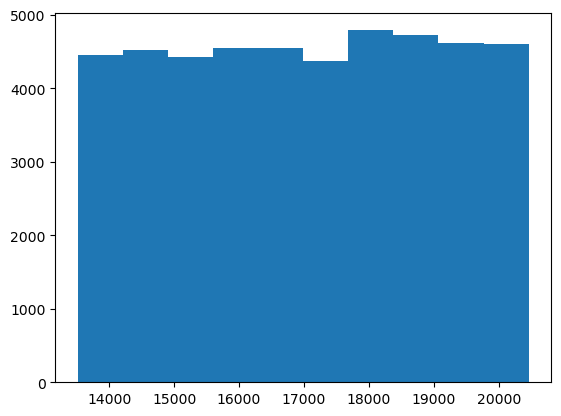

In [248]:
plt.hist(date2num(df_pred_stereo.juldate))

(array([4465., 4270., 4375., 4514., 4197., 4470., 4471., 4486., 4493.,
        4402.]),
 array([13516.7103 , 14210.63545, 14904.5606 , 15598.48575, 16292.4109 ,
        16986.33605, 17680.2612 , 18374.18635, 19068.1115 , 19762.03665,
        20455.9618 ]),
 <BarContainer object of 10 artists>)

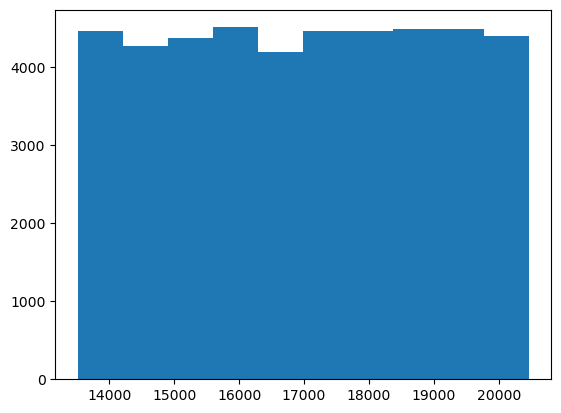

In [249]:
plt.hist(date2num(df_pred_earth.juldate))

(array([16712., 16671., 16674., 16677., 16885., 16679., 16789., 16662.,
        16656., 16658.]),
 array([13514.   , 14207.996, 14901.992, 15595.988, 16289.984, 16983.98 ,
        17677.976, 18371.972, 19065.968, 19759.964, 20453.96 ]),
 <BarContainer object of 10 artists>)

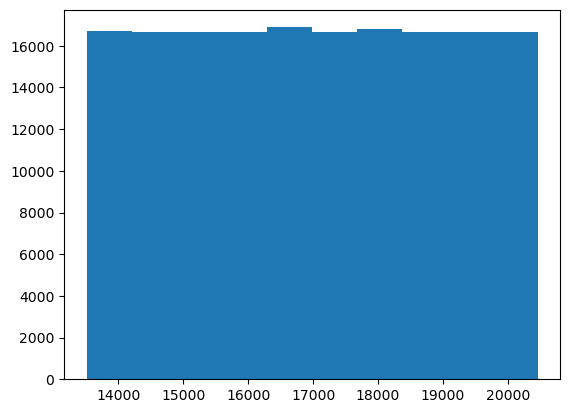

In [250]:
plt.hist(date2num(df_obs_stereo.juldate))

(array([12732., 12732., 12732., 12732., 12732., 12732., 12732., 12732.,
        12732., 12732.]),
 array([14610.   , 15140.496, 15670.992, 16201.488, 16731.984, 17262.48 ,
        17792.976, 18323.472, 18853.968, 19384.464, 19914.96 ]),
 <BarContainer object of 10 artists>)

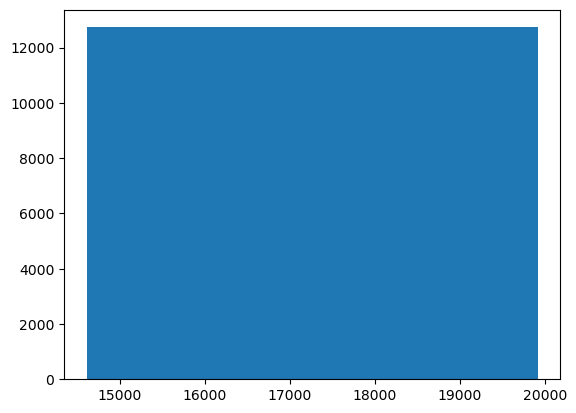

In [251]:
plt.hist(date2num(df_obs_earth.juldate))

# Remove CME's from stereo

In [252]:
def parse_space_date(date_str):
    # Split the string from the right on the first space 
    # e.g., "2011 7/23 9:41" -> date_part="2011 7/23", time_part="9:41"
    
    # Check if there is a decimal point in the time
    if '.' in date_str:
        date_part, time_part = date_str.rsplit(' ', 1)

        # Split into the whole minutes and the decimal fraction
        time_base, time_fraction = time_part.split('.')
        
        # Parse the base date (e.g., "2011 7/23 9:41")
        base_time_str = f"{date_part} {time_base}"
        base_dt = pd.to_datetime(base_time_str, format='%Y %m/%d %H:%M')
        
        # Calculate the extra seconds 
        # Note: We multiply by 60 assuming these are fractional minutes.
        # (If they are actually fractions of a second, just change `* 60` to `* 1`)
        extra_seconds = float(f"0.{time_fraction}") * 60 
        
        return base_dt + pd.Timedelta(seconds=extra_seconds)
    
    else:
        # No decimal present, just parse the whole string directly
        return pd.to_datetime(date_str, format='%Y %m/%d %H:%M')


## Remove CMEs in STEREO

In [253]:
df_stereo_cme = df = pd.read_excel('STEREO_Level3_ICME.xlsx', skiprows=8) 
df_stereo_cme = df_stereo_cme[~pd.isna(df_stereo_cme['STEREO']) ]
df_stereo_cme.columns

Index(['#', 'STEREO', 'Start time [Year Month/Day HH:MM] ',
       'Magnetic obstacle (~ flux rope) start time1', 'End time',
       'Ptmax [pPa]', 'Bmax [nT]', 'Vmax [km/s]', '∆V2 [km/s]', 'Group3',
       'MC (2 for better defined)', 'Comment'],
      dtype='object')

In [254]:
for _, row in df_stereo_cme.iterrows():
    if 'A' in row['STEREO']:
        stime_str = row['Start time [Year Month/Day HH:MM] ']
        try:
            stime = parse_space_date(stime_str)
        except Exception as e:
            print(stime_str)
            continue
        etime = parse_space_date(row['End time'])
        df_obs_stereo.loc[(df_obs_stereo.juldate > stime) & (df_obs_stereo.juldate < etime), 'Vp_obs'] = np.nan

2013 2:45.725
2023 02/20 00:39 
2024/11/20 07:56
2025/05/30 09:37


## Remove CMEs in Earth

In [255]:
# Remove CME events from ace_aligned using icmetable2.xlsx
icme = pd.read_excel(r'./icmetable2.xlsx')

for i in range(len(icme)):
    stime = pd.to_datetime(str(icme.iloc[i, 0]).split('(')[0].strip())
    etime = pd.to_datetime(str(icme.iloc[i, 2]).split('(')[0].strip())
    df_obs_earth.loc[(df_obs_earth.juldate > stime) & (df_obs_earth.juldate < etime), 'Vp_obs'] = np.nan


# Plot all data

In [256]:
df_obs_stereo.loc[df_obs_stereo.Vp_obs < 200, 'Vp_obs'] = np.nan

Text(0, 0.5, 'km/s')

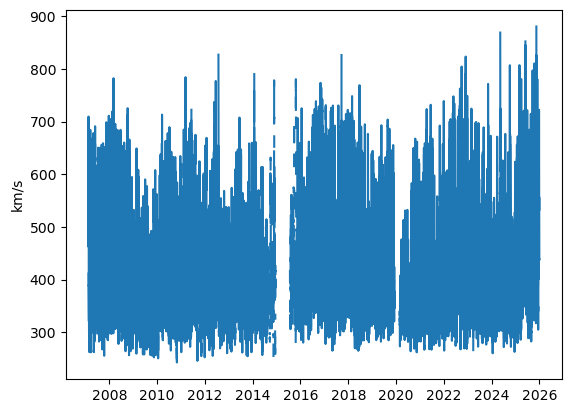

In [257]:
plt.plot(df_obs_stereo.juldate, df_obs_stereo.Vp_obs)
plt.ylabel('km/s')

(array([ 8489.,  8360.,  8402.,  7776.,  7555.,  7241.,  4865.,  1623.,
         8476.,  8382.,  8251.,  7900.,  6918.,  8229.,  8376.,  7968.,
        16358.]),
 array([2008., 2009., 2010., 2011., 2012., 2013., 2014., 2015., 2016.,
        2017., 2018., 2019., 2020., 2021., 2022., 2023., 2024., 2025.]),
 <BarContainer object of 17 artists>)

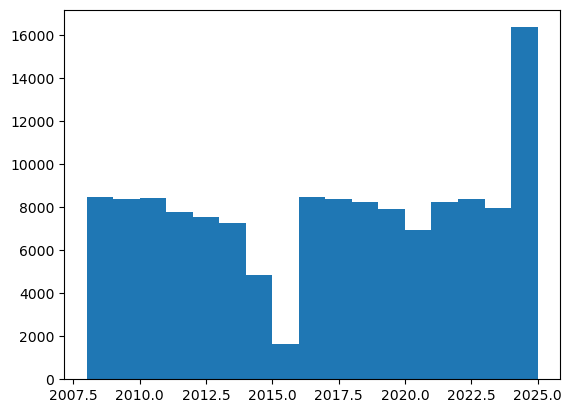

In [258]:
plt.hist([row.year for _, row in df_obs_stereo.iterrows() if not pd.isna(row.Vp_obs)], bins=np.arange(2008, 2026))

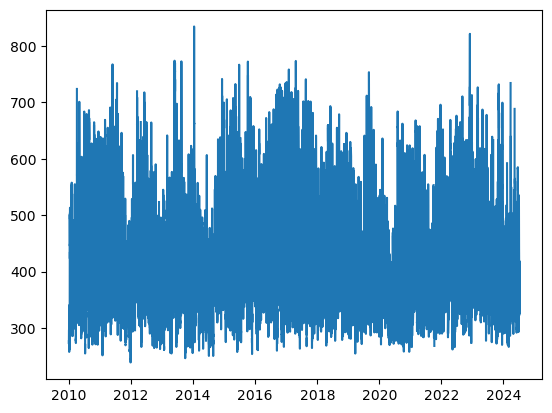

In [259]:
plt.plot(df_obs_earth.juldate, df_obs_earth.Vp_obs)

## Investigate NaN's

In [260]:
mask = np.isfinite(df_obs_earth.Vp_obs)
mask.sum() / mask.size

0.9219839773798304

In [261]:
mask = np.isfinite(df_obs_stereo.Vp_obs)
mask.sum() / mask.size

0.854288501942381

## Align Predictions and Observational Data

In [262]:
df_pred_stereo_tmp = (
    df_pred_stereo[['juldate', 'Vp']]
    .set_index('juldate')
    .resample('6h')
    .mean()
    .reset_index()
)
df_final_stereo = pd.merge_asof(
    df_obs_stereo, 
    df_pred_stereo_tmp, 
    on='juldate', 
    direction='nearest'
)


df_pred_earth_tmp = (
    df_pred_earth[['juldate', 'Vp']]
    .set_index('juldate')
    .resample('6h')
    .mean()
    .reset_index()
)
df_final_earth = pd.merge_asof(
    df_obs_earth, 
    df_pred_earth_tmp, 
    on='juldate', 
    direction='nearest'
)

# Plot by Year

In [263]:
def plot_by_year(df, label):
    yearmin = df.juldate.min().year
    yearmax = df.juldate.max().year

    d = {}

    for year in range(2010, yearmax + 1):
        mask = np.array([d.year == year for d in df.juldate])

        print(year, mask.sum())
    
        #if mask.sum() < 5000:
        #    d[year] = np.nan
        #    continue
            
        d[year] = np.sqrt(np.nanmean(np.square(df[mask].Vp_obs - df[mask].Vp)))
        
    plt.plot(d.keys(), d.values(), label=label)

2010 8771
2011 8763
2012 8799
2013 8768
2014 8893
2015 8867
2016 8808
2017 8760
2018 8776
2019 8820
2020 8842
2021 8765
2022 8760
2023 8760
2024 8786
2025 8760
2010 8760
2011 8760
2012 8784
2013 8760
2014 8760
2015 8760
2016 8784
2017 8760
2018 8760
2019 8760
2020 8784
2021 8760
2022 8760
2023 8760
2024 4608


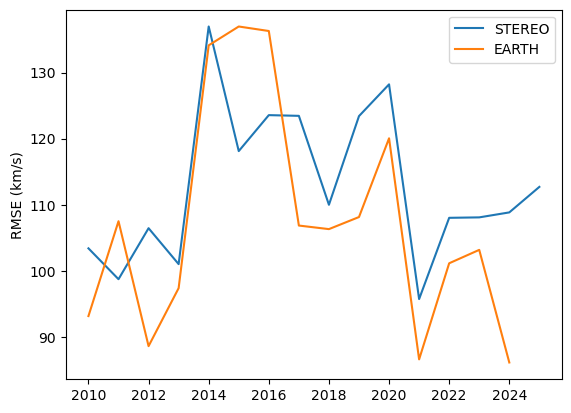

In [264]:
plot_by_year(df_final_stereo, 'STEREO')
plot_by_year(df_final_earth, 'EARTH')
plt.ylabel('RMSE (km/s)')
plt.legend()

In [265]:
df_final_stereo.size / df_final_earth.size

1.3121504869619856

# Compute by Angular Separations

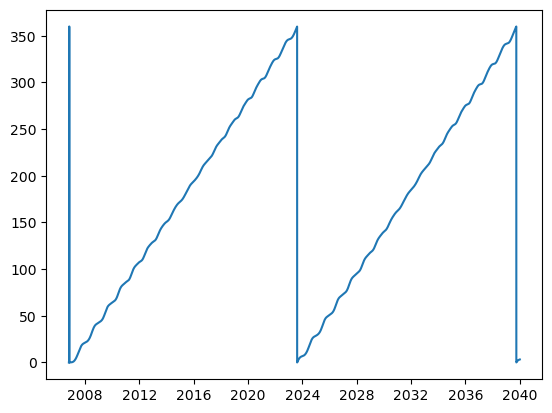

In [304]:
df_locs = df_locs_stereo.merge(df_locs_earth, on='sat_time_jd', suffixes=('_stereo', '_earth'))

# daily separations, then circular mean (don't average longitudes first)
delta = (df_locs['sat_lon_stereo'] - df_locs['sat_lon_earth']) % 360
df_locs['sep'] = np.rad2deg(np.angle(np.exp(1j * np.deg2rad(delta)))) % 360

plt.plot(df_locs.juldate_earth, df_locs['sep'])

In [305]:
df_final_stereo['stereo_angle'] = np.interp(date2num(df_final_stereo.juldate), date2num(df_locs.juldate_stereo), df_locs.sep)

In [306]:
df_final_earth['stereo_angle'] = np.interp(date2num(df_final_earth.juldate), date2num(df_locs.juldate_stereo), df_locs.sep)

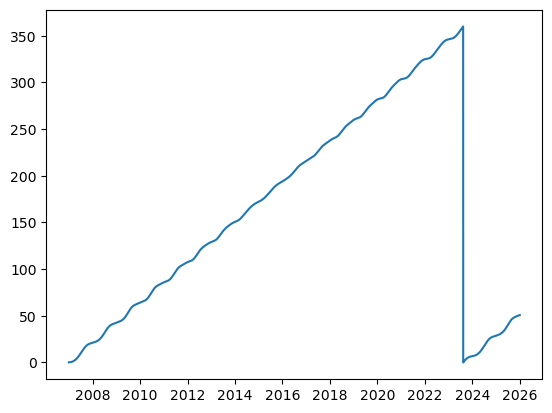

In [307]:
plt.plot(df_final_stereo.juldate, df_final_stereo.stereo_angle)

In [308]:
df_final_earth['stereo_angle'].describe()

count    127320.000000
mean        198.779976
std          95.909153
min           0.004733
25%         124.852364
50%         200.564736
75%         281.479642
max         359.909399
Name: stereo_angle, dtype: float64

In [309]:
regions = [((i * np.pi / 2) + np.pi/4, ((i + 1) * np.pi / 2) + np.pi/4) for i in range(4)]

for i, region in enumerate(regions):
    print(f"Quadrant {i}: {region[0]:.3f} to {region[1]:.3f} radians")

Quadrant 0: 0.785 to 2.356 radians
Quadrant 1: 2.356 to 3.927 radians
Quadrant 2: 3.927 to 5.498 radians
Quadrant 3: 5.498 to 7.069 radians


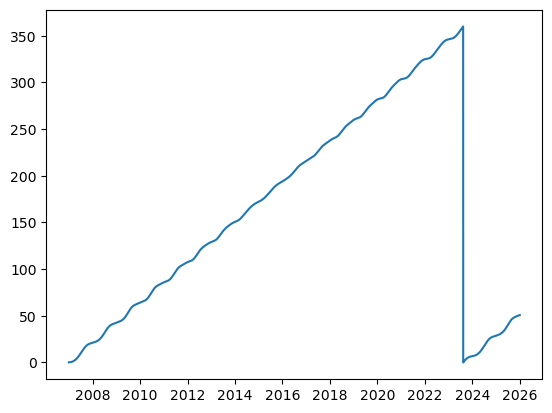

In [312]:
plt.plot(df_final_stereo.juldate, df_final_stereo.stereo_angle)

In [317]:
def format_year_ranges(years):
    # Handle empty lists
    if not years:
        return ""

    # Sort the list and remove any duplicates
    sorted_years = sorted(set(years))
    
    ranges = []
    start = sorted_years[0]
    end = sorted_years[0]

    for year in sorted_years[1:]:
        if year == end + 1:
            # The year is consecutive; extend the current range
            end = year
        else:
            # The year is not consecutive; save the previous range
            if start == end:
                ranges.append(str(start))
            else:
                ranges.append(f"{start}-{end}")
            
            # Start a new range
            start = year
            end = year

    # Don't forget to append the final range after the loop finishes
    if start == end:
        ranges.append(str(start))
    else:
        ranges.append(f"{start}-{end}")

    # Join the ranges into a single string
    return ", ".join(ranges)


[2009, 2010, 2011, 2012, 2013, 2023, 2025]
[2013, 2014, 2015, 2016, 2017, 2023]
[2017, 2018, 2019, 2020, 2021, 2023]
[2007, 2008, 2009, 2021, 2022, 2023, 2024, 2025]
3.417154007769524


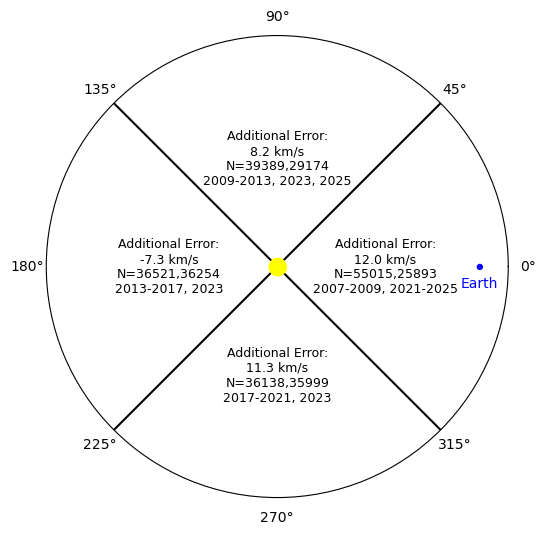

In [321]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
tmp =0

errors = []

for a, b in regions:
    a = np.rad2deg(a)
    b = np.rad2deg(b)
    stereo_mask = (df_final_stereo.stereo_angle > a) & (df_final_stereo.stereo_angle  < b)
    if b > 360:
        stereo_mask |= (df_final_stereo.stereo_angle < b - 360)

    earth_mask = (df_final_earth.stereo_angle > a) & (df_final_earth.stereo_angle  < b)
    if b > 360:
        earth_mask |= (df_final_earth.stereo_angle < b - 360)
    
    err_stereo = np.sqrt(np.nanmean(np.square(df_final_stereo.loc[stereo_mask, 'Vp_obs'] - df_final_stereo.loc[stereo_mask, 'Vp'])))
    err_earth = np.sqrt(np.nanmean(np.square(df_final_earth.loc[earth_mask, 'Vp_obs'] - df_final_earth.loc[earth_mask, 'Vp'])))

    #err_stereo = np.nanmean(np.abs(df_final_stereo.loc[stereo_mask, 'Vp_obs'] - df_final_stereo.loc[stereo_mask, 'Vp']))
    #err_earth = np.nanmean(np.abs(df_final_earth.loc[earth_mask, 'Vp_obs'] - df_final_earth.loc[earth_mask, 'Vp']))

    stereo_years = sorted(set(juldate.year for juldate in df_final_stereo.loc[stereo_mask, 'juldate']))
    print(stereo_years)
    ax.text(np.deg2rad(a + b) / 2, 1.5, f'Additional Error:\n{err_stereo-err_earth:.1f} km/s\nN={stereo_mask.sum()},{earth_mask.sum()}\n{format_year_ranges(stereo_years)}', 
            fontsize=9, ha='center', va='center')
    ax.plot([np.deg2rad(a), np.deg2rad(a)], [0, 3.2], 'k-')
    
    ax.grid(0)
    tmp += mask.sum()
    ax.set_rticks([])


ax.set_rlim(0, 3.2)

# Plot the sun
theta = np.linspace(0, 2 * np.pi, 100)
radius = np.full_like(theta, .1) 
ax.fill_between(theta, 0, radius, color='yellow', linewidth=3, zorder=999)

ax.text(0, 2.8, '⚫', color='blue', ha='center', va='center')
ax.text(0, 2.8, '\n\nEarth', color='blue', ha='center', va='center')

print(tmp/len(df_final_stereo))